In [20]:
# Trajectory sampler
# ================================
# This section performs sampling of the original descriptors matrix or reduced ones from dim_red.ipynb to generate an initial dataset


In [21]:
import os, glob, json
import numpy as np
import pandas as pd
from sampler_utils import sample, atoms_to_structures, load_reduced, pc_coverage_bins, pc_coverage_bins_auto
from dim_red_utils import load_pca_model
import matplotlib.pyplot as plt
from plots_exports_utils import plot_sampling_pca, export_selected_structures, export_methods_bundle

In [ ]:
# X can be the original standardized SOAP or a reduced matrix (e.g., PCA)
embedded_file = True 
if embedded_file:
    # Look for .npy file in embedding/ directory
    npy_files = glob.glob("embedding/*.npy")
    if not npy_files:
        raise FileNotFoundError("No .npy file found in embedding/ directory")
    if len(npy_files) > 1:
        raise RuntimeError(f"Multiple .npy files found: {npy_files}")
    npy_file = npy_files[0]
    print(f"Using embedding: {npy_file}")

    X = load_reduced(npy_file)  # or use np.load directly
    print("Loaded embedding with shape:", X.shape)

    pca_model_file = glob.glob("embedding/*.json") 
    if not pca_model_file:
        raise FileNotFoundError("No PCA model .json file found in embedding/ directory")
    if len(pca_model_file) > 1:
        raise RuntimeError(f"Multiple PCA model files found: {pca_model_file}")
    pca_model_file = pca_model_file[0]
    print(f"Using PCA model: {pca_model_file}")
    pca_model = load_pca_model(pca_model_file)
    
else: 
    # Look for .npy file in current directory
    npy_files = glob.glob("./*.npy")
    if not npy_files:
        raise FileNotFoundError("No .npy file found in current directory")
    if len(npy_files) > 1:
        raise RuntimeError(f"Multiple .npy files found: {npy_files}")
    npy_file = npy_files[0]
    print(f"Using standardized SOAP matrix: {npy_file}")

# Find provenance parquet file
parquet_files = glob.glob("*.parquet")
if not parquet_files:
    raise FileNotFoundError("No provenance .parquet file found in current directory")
if len(parquet_files) > 1:
    raise RuntimeError(f"Multiple parquet files found: {parquet_files}")
parquet_file = parquet_files[0]
print(f"Using provenance file: {parquet_file}")
meta = pd.read_parquet(parquet_file)

# Match corresponding JSON file with same timestamp
json_file = glob.glob("*.json")
if not json_file:
    raise FileNotFoundError(f"No filemap JSON found")
if len(json_file) > 1:
    raise RuntimeError(f"Multiple JSON matches found: {json_file}")
json_file = json_file[0]
print(f"Using filemap: {json_file}")
with open(json_file) as f:
    filemap = json.load(f)

# specify the directory where sampling results are saved
path_to_results = "./selected" # Change if you want to save results elsewhere
os.makedirs(path_to_results, exist_ok=True)

Using embedding: embedding/pca_embedding.npy
Loaded embedding with shape: (11552338, 4)
Using PCA model: embedding/pca_model.json
Using provenance file: SOAP_O-N-C_provenance_20250917-112705.parquet
Using filemap: SOAP_O-N-C_filemap_20250917-112705.json


In [23]:
print("X dtype/shape:", X.dtype, X.shape)
print("has_nan:", np.isnan(X).any(), "has_inf:", np.isinf(X).any(),
      "abs max:", np.nanmax(np.abs(X)))

X dtype/shape: float64 (11552338, 4)
has_nan: False has_inf: False abs max: 41.431714955625324


## FPS sampling

Using Farthest-Point Sampling (FPS) ...


FPS: 100%|██████████| 2499/2499 [04:51<00:00,  8.57it/s]


Selected 2378 unique structures.
Mean coverage: 0.7463647590392783
Per-PC bins used: [372, 526, 513, 257]
Per-PC coverage: [0.7351190476190477, 0.763671875, 0.5956175298804781, 0.8910505836575876]


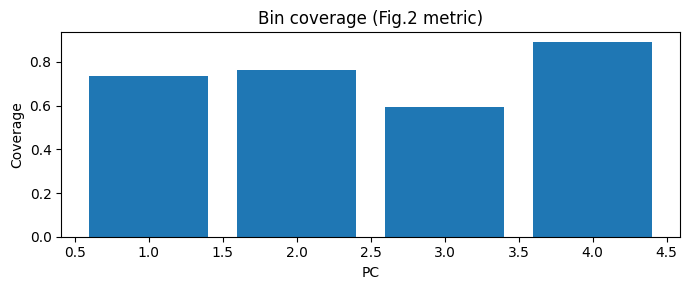

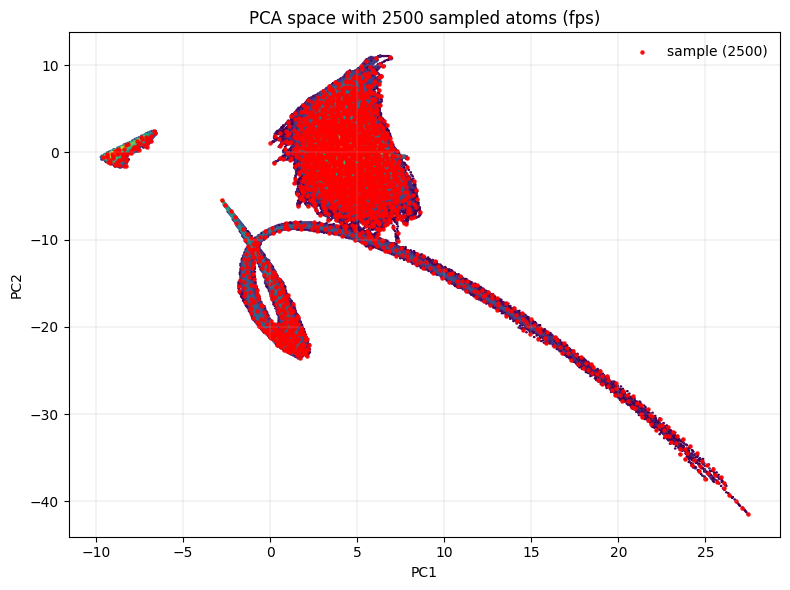

Loading structures: 100%|██████████| 2378/2378 [29:06<00:00,  1.36it/s]


{'traj': 'selected/FPS_selected.traj', 'xyz': 'selected/FPS_selected.xyz'}


In [ ]:
# pick a sampler
#  "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
method="fps"
idx_atoms = sample(X, method=method, k=2500, progress=True)
#idx = sample(X, method="kpp", k=50000, progress=True)
#idx = sample(X, method="kmedoids", k=10000, progress=True)
#idx = sample(X, method="hdbscan", k=0, min_cluster_size=40, per_cluster=2, progress=True)

# lift to structures
chosen_structs = atoms_to_structures(idx_atoms, meta, filemap, choose="all")#choose="top", top_k=200)

# save
np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx_atoms)
chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
    X, idx_atoms, mode="width", target_width=0.1, min_bins=20, max_bins=10000
)
print("Mean coverage:", mean_cov)
print("Per-PC bins used:", bins_used[:8])
print("Per-PC coverage:", per_pc)

plot_sampling_pca(X, idx_atoms, method="fps", per_pc=per_pc, npy_file=npy_file)

# One method
save_files_fps = True
if save_files_fps:
    paths = export_selected_structures(chosen_structs, method_name="FPS", outdir=path_to_results, extra_formats=("xyz"))
    print(paths)

## Random sampling

Using random sampling ...
Selected 2469 unique structures.
Mean coverage: 0.29090987284764036
Per-PC bins used: [372, 526, 513, 257]
Per-PC coverage: [0.33630952380952384, 0.28515625, 0.22310756972111553, 0.31906614785992216]


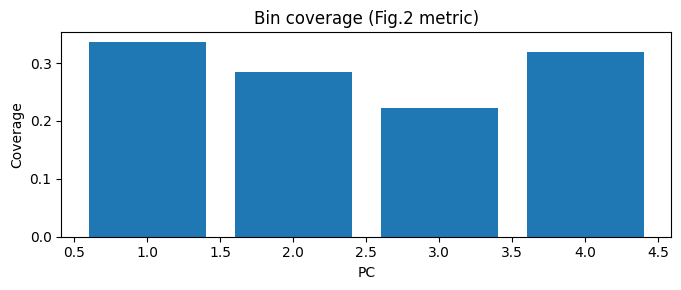

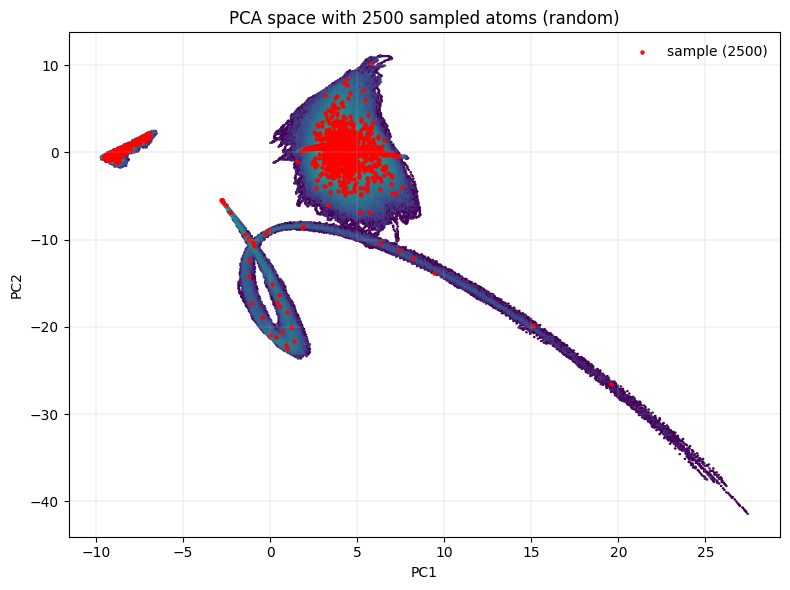

Loading structures: 100%|██████████| 2469/2469 [30:35<00:00,  1.35it/s]


{'traj': 'selected/Random_selected.traj', 'xyz': 'selected/Random_selected.xyz'}


In [ ]:
# pick a sampler
#  "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
method="random"
idx_atoms = sample(X, method=method, seed=42, k=2500, progress=True)
#idx = sample(X, method="kpp", k=50000, progress=True)
#idx = sample(X, method="kmedoids", k=10000, progress=True)
#idx = sample(X, method="hdbscan", k=0, min_cluster_size=40, per_cluster=2, progress=True)

# lift to structures
chosen_structs = atoms_to_structures(idx_atoms, meta, filemap, choose="all") #choose="top", top_k=200)
#print(chosen_structs.head())

# save
np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx_atoms)
chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
    X, idx_atoms, mode="width", target_width=0.1, min_bins=20, max_bins=10000
)
print("Mean coverage:", mean_cov)
print("Per-PC bins used:", bins_used[:8])
print("Per-PC coverage:", per_pc)

plot_sampling_pca(X, idx_atoms, method="random", per_pc=per_pc, npy_file=npy_file)

# One method
save_files_rdn = True
if save_files_rdn:
    paths = export_selected_structures(chosen_structs, method_name="Random", outdir=path_to_results, extra_formats=("xyz"))
    #paths =export_selected_structures(chosen_structs, method_name="FPS", write_traj=False, extra_formats=("xyz",))
    print(paths)

## BIRCH

Stratified pick: 100%|██████████| 100/100 [00:01<00:00, 71.93it/s]


{'n_clusters': 100, 'k_per_cluster': 25, 'selected': 2500, 'threshold': 0.5, 'branching_factor': 50}
Selected 2450 unique structures.
Mean coverage: 0.8239129021164047
Per-PC bins used: [372, 526, 513, 257]
Per-PC coverage: [0.8541666666666666, 0.826171875, 0.6892430278884463, 0.9260700389105059]


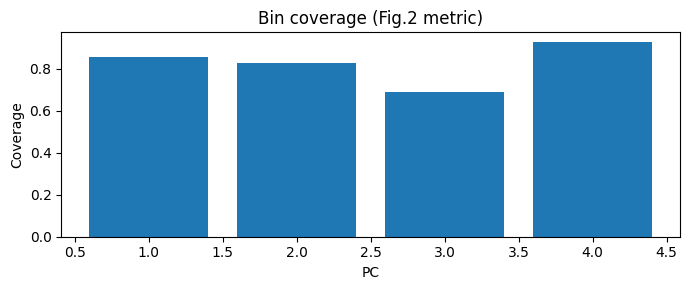

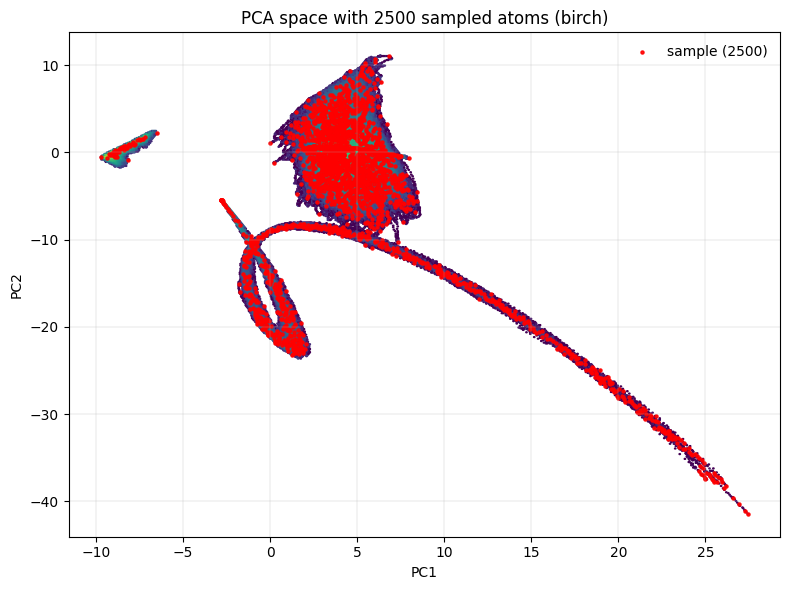

Loading structures: 100%|██████████| 2450/2450 [30:04<00:00,  1.36it/s]


{'traj': 'selected/Birch_selected.traj', 'xyz': 'selected/Birch_selected.xyz'}


In [ ]:
# inputs: PCA embedding Z (all rows), explained_variance EV (from your saved JSON)
from sampler_utils import direct_birch_sample, pc_bin_coverage

idx, info = direct_birch_sample(
    Z_pca=X, ev=pca_model.explained_variance_,
    n_clusters=100,          # or None → CF subclusters
    threshold=0.5,
    branching_factor=50,
    k_per_cluster=25,
    progress=True
)
print(info)

# lift to structures with your existing atoms_to_structures(...)
chosen_structs = atoms_to_structures(idx, meta, filemap, choose="all")

# save
method="birch"
np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx)
chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
    X, idx, mode="width", target_width=0.1, min_bins=20, max_bins=10000
)
print("Mean coverage:", mean_cov)
print("Per-PC bins used:", bins_used[:8])
print("Per-PC coverage:", per_pc)

plot_sampling_pca(X, idx, method="birch", per_pc=per_pc, npy_file=npy_file)

# One method
save_files_birch = True
if save_files_birch:
    paths = export_selected_structures(chosen_structs, method_name="Birch", outdir=path_to_results, extra_formats=("xyz"))
    #paths =export_selected_structures(chosen_structs, method_name="FPS", write_traj=False, extra_formats=("xyz",))
    print(paths)

Using k-means++ sampling ...


k-means++: 100%|██████████| 2499/2499 [06:53<00:00,  6.05it/s]


Selected 2468 unique structures.
Mean coverage: 0.5258249801856821
Per-PC bins used: [372, 526, 513, 257]
Per-PC coverage: [0.5297619047619048, 0.556640625, 0.3904382470119522, 0.6264591439688716]


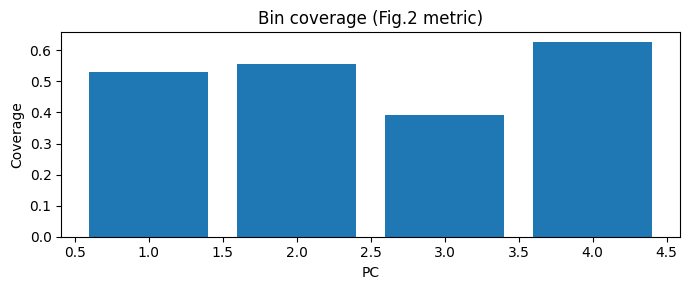

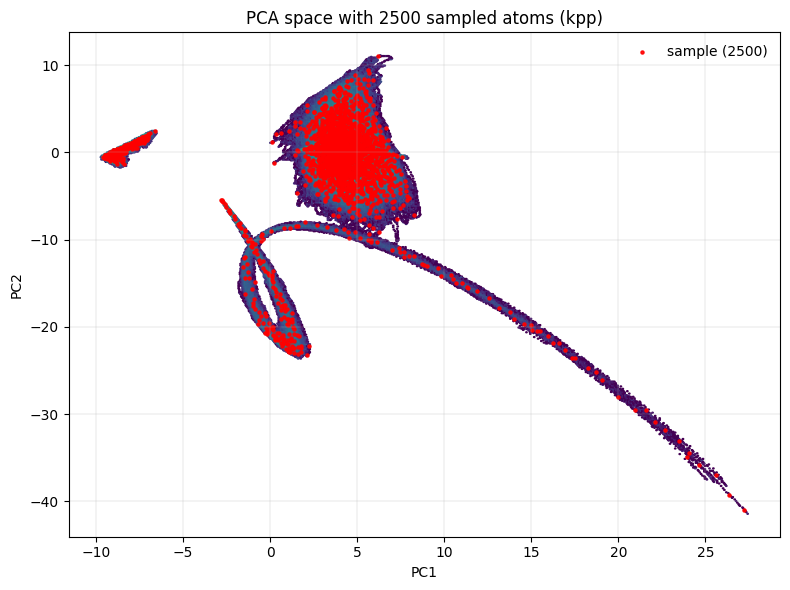

Loading structures: 100%|██████████| 2468/2468 [30:14<00:00,  1.36it/s]


{'traj': 'selected/KPP_selected.traj', 'xyz': 'selected/KPP_selected.xyz'}


In [ ]:
# pick a sampler
#  "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
method="kpp"
idx = sample(X, method="kpp", k=2500, progress=True)

# lift to structures
chosen_structs = atoms_to_structures(idx, meta, filemap, choose="all") #choose="top", top_k=200)
#print(chosen_structs.head())

# save
np.save(os.path.join(path_to_results, f"sampled_atom_indices_{method}.npy"), idx)
chosen_structs.to_csv(os.path.join(path_to_results, f"sampled_structures_{method}.csv"), index=False)

per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
    X, idx, mode="width", target_width=0.1, min_bins=20, max_bins=10000
)
print("Mean coverage:", mean_cov)
print("Per-PC bins used:", bins_used[:8])
print("Per-PC coverage:", per_pc)

plot_sampling_pca(X, idx, method="kpp", per_pc=per_pc, npy_file=npy_file)

# One method
save_files_kpp = True
if save_files_kpp:
    paths = export_selected_structures(chosen_structs, method_name="KPP", outdir=path_to_results, extra_formats=("xyz"))
    #paths =export_selected_structures(chosen_structs, method_name="FPS", write_traj=False, extra_formats=("xyz",))
    print(paths)